# 04 · Backtesting the strategy - with real costs

**Supports agenda block 8** ("Backtesting the Strategy") and sets up
block 10 ("Where to Go Next... why most backtests break"). We turn the
out-of-sample predictions from `03_model_training` into a monthly
top-N, equal-weight ETF portfolio and run it through `ml4t-backtest`'s
event-driven engine - **with commissions and slippage switched on
explicitly**.

That last clause is not boilerplate. `BacktestConfig` defaults
`commission_type` and `slippage_type` to `NONE` - a config that *sets*
`commission_rate`/`slippage_rate` without also setting the corresponding
`*_type` field runs at **zero cost**, silently. It's an easy mistake to
make (and one worth checking for explicitly if you ever hand this brief
to a coding agent) since the cost fields look like they should be enough
on their own.

In [1]:
import os
import subprocess
import sys
from pathlib import Path


def run_notebook(name):
    """Execute a prerequisite notebook's own code cells as a plain script.

    The derived parquet files are gitignored, so a fresh clone that opens this
    notebook first has to build them. `nbconvert --execute` cannot do it here: it
    starts a second Jupyter kernel, which Colab refuses with "Kernel died before
    replying to kernel_info". Concatenating the notebook's code cells keeps the
    .ipynb the single source of truth - an exported .py committed beside it would
    be a second copy free to drift. The bootstrap cell is skipped so this does not
    recurse.
    """
    import json
    import tempfile

    cells = json.loads(Path(name).read_text())["cells"]
    code = "\n\n".join(
        "".join(cell["source"])
        for cell in cells
        if cell["cell_type"] == "code" and "COLAB_RELEASE_TAG" not in "".join(cell["source"])
    )
    with tempfile.NamedTemporaryFile("w", suffix=".py", dir=".", delete=False) as handle:
        handle.write(code)
        script = handle.name
    try:
        subprocess.run([sys.executable, script], check=True)
    finally:
        os.unlink(script)


if "COLAB_RELEASE_TAG" in os.environ:
    repo_dir = Path(os.environ.get("PACKT_WORKSHOP_DIR", "/content/packt-workshop"))
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/ml4t/packt-workshop.git",
                repo_dir,
            ],
            check=True,
        )
    ready = repo_dir.parent / ".packt-workshop-ready"
    if not ready.exists():
        # Colab's kernel already has numpy imported before this cell runs. Installing a
        # different numpy from requirements-colab.txt overwrites the files on disk but not
        # the compiled submodules already cached in this process, so importing a numpy
        # submodule for the first time later (e.g. via ml4t.engineer) mixes the new files
        # with the stale cached extension and raises ImportError. Put numpy back to the
        # version this process already has loaded once the rest of the install is done.
        import numpy as _colab_numpy

        colab_numpy_version = _colab_numpy.__version__
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-r",
                repo_dir / "requirements-colab.txt",
            ],
            check=True,
        )
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "--force-reinstall",
                "--no-deps",
                f"numpy=={colab_numpy_version}",
            ],
            check=True,
        )
        ready.touch()
    os.chdir(repo_dir / "notebooks")
    if not (repo_dir / "data/model_dataset.parquet").exists():
        print("Preparing the feature-and-label dataset required by this notebook.")
        run_notebook("02_features_labels.ipynb")
    if not (repo_dir / "data/oos_predictions.parquet").exists():
        print("Preparing the out-of-sample predictions required by this notebook.")
        run_notebook("03_model_training.ipynb")

In [2]:
from dataclasses import asdict

import pandas as pd
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    Broker,
    RebalanceConfig,
    Strategy,
    TargetWeightExecutor,
    run_backtest,
)
from ml4t.backtest.config import CommissionType, ShareType, SlippageType, SpreadConvention
from ml4t.backtest.execution.schedule import RebalanceCadence, RebalanceSchedule

DATA_DIR = "../data"

prices = pd.read_parquet(f"{DATA_DIR}/etf_universe.parquet")
prices["timestamp"] = pd.to_datetime(prices["timestamp"])

oos = pd.read_parquet(f"{DATA_DIR}/oos_predictions.parquet")
oos["timestamp"] = pd.to_datetime(oos["timestamp"]).dt.tz_localize(None)

# The engine wants prices covering exactly the OOS prediction window -
# trading on dates the model never produced a signal for isn't meaningful.
prices = prices[
    (prices["timestamp"] >= oos["timestamp"].min())
    & (prices["timestamp"] <= oos["timestamp"].max())
]

prices_pl = pl.from_pandas(
    prices[["timestamp", "symbol", "open", "high", "low", "close", "volume"]]
)
signals_pl = pl.from_pandas(oos[["timestamp", "symbol", "prediction"]])

print(f"backtest window: {prices['timestamp'].min().date()} -> {prices['timestamp'].max().date()}")
print(f"{prices_pl.height:,} price rows, {signals_pl.height:,} signal rows")

backtest window: 2015-12-28 -> 2023-12-29
200,977 price rows, 188,122 signal rows


## The cost model - matches the book's own ETF case study

`$0.0035`/share commission and tiered half-spread slippage are the same
numbers the case study's `config/setup.yaml` uses (`per_share_plus_spread`,
IBKR Pro tiered pricing). We use the real numbers rather than a round
"50 bps" placeholder, because the point of this block is that the *shape*
of a realistic cost model - fixed-plus-spread, not a flat percentage -
changes which trades are worth making at all, especially for the
less-liquid names in a 100-ETF universe.

In [3]:
ASSET_SPREADS = {
    "SPY": 0.005,
    "QQQ": 0.005,
    "IWM": 0.005,
    "EFA": 0.005,
    "EEM": 0.005,
    "DIA": 0.005,
    "VTI": 0.005,
    "XLK": 0.01,
    "XLF": 0.01,
    "XLV": 0.01,
    "XLE": 0.01,
    "XLY": 0.01,
    "XLI": 0.01,
    "XLP": 0.01,
    "XLU": 0.01,
    "XLB": 0.01,
    "XLRE": 0.01,
    "XLC": 0.01,
}

config = BacktestConfig(
    initial_cash=100_000.0,
    share_type=ShareType.INTEGER,
    commission_type=CommissionType.PER_SHARE,
    commission_per_share=0.0035,
    slippage_type=SlippageType.SPREAD,
    slippage_spread=0.02,  # default half-spread for anything not in the table below
    slippage_spread_by_asset=ASSET_SPREADS,
    slippage_spread_convention=SpreadConvention.HALF_SPREAD,
)
print(config.validate())  # empty list = no configuration warnings

[]


## The strategy: monthly top-10, equal weight

Rank the current cross-section by predicted 21-day forward return, take
the top 10, equal-weight them, rebalance at month end. `RebalanceConfig`
carries the same trade-filtering thresholds as the case study
(`min_weight_change=0.005`, `min_trade_value=$100`) so the backtest
doesn't churn on economically meaningless rebalances.

In [4]:
TOP_N = 10

executor = TargetWeightExecutor(
    config=RebalanceConfig(
        schedule=RebalanceSchedule(cadence=RebalanceCadence.MONTH_END),
        min_weight_change=0.005,
        min_trade_value=100.0,
    )
)


class TopNRebalanceStrategy(Strategy):
    def __init__(self, top_n: int, executor: TargetWeightExecutor):
        self.top_n = top_n
        self.executor = executor

    def on_prepare(self, broker: Broker, timestamps, config=None) -> None:
        self.executor.prepare_schedule(timestamps)

    def on_data(self, timestamp, data, context, broker: Broker) -> None:
        preds = {
            asset: bar["signals"]["prediction"]
            for asset, bar in data.items()
            if bar.get("signals") and bar["signals"].get("prediction") is not None
        }
        if not preds:
            return
        ranked = sorted(preds.items(), key=lambda kv: kv[1], reverse=True)[: self.top_n]
        weight = 1.0 / len(ranked)
        target_weights = {asset: weight for asset, _ in ranked}
        self.executor.execute(target_weights, data, broker, timestamp=timestamp)


strategy = TopNRebalanceStrategy(top_n=TOP_N, executor=executor)

## Run it twice: with and without costs

The only way to see what costs actually cost is to run the identical
strategy both ways and diff the result - not to quote a rule-of-thumb
bps haircut.

In [5]:
result_with_costs = run_backtest(prices_pl, strategy, signals=signals_pl, config=config)

zero_cost_config = BacktestConfig(initial_cash=100_000.0, share_type=ShareType.INTEGER)
strategy_zero_cost = TopNRebalanceStrategy(
    top_n=TOP_N,
    executor=TargetWeightExecutor(
        config=RebalanceConfig(
            schedule=RebalanceSchedule(cadence=RebalanceCadence.MONTH_END),
            min_weight_change=0.005,
            min_trade_value=100.0,
        )
    ),
)
result_zero_cost = run_backtest(
    prices_pl, strategy_zero_cost, signals=signals_pl, config=zero_cost_config
)

In [6]:
comparison = pd.DataFrame(
    {
        "zero_cost": result_zero_cost.metrics,
        "with_costs": result_with_costs.metrics,
    }
)
print(
    comparison.loc[
        ["total_return_pct", "sharpe", "max_drawdown_pct", "cagr", "avg_turnover", "total_costs"]
    ]
)

assert abs(comparison.loc["sharpe", "zero_cost"] - 0.477991) < 1e-5
assert abs(comparison.loc["sharpe", "with_costs"] - 0.440466) < 1e-5
assert abs(comparison.loc["avg_turnover", "with_costs"] - 0.059523) < 1e-5
assert abs(comparison.loc["total_costs", "with_costs"] - 8_596.84) < 1.0

                  zero_cost   with_costs
total_return_pct  91.512744    79.136041
sharpe             0.477991     0.440466
max_drawdown_pct  46.523740    46.567223
cagr               0.084583     0.075566
avg_turnover       0.059483     0.059523
total_costs        0.000000  8596.838000


## Visualizing the cost gap

The table above is the summary; this is the path it summarizes. Same
signal, same rebalance dates - the with-costs line only diverges from the
zero-cost line at each month-end trade, and the underwater chart shows
that the two share the same drawdown shape rather than costs adding a
separate risk.

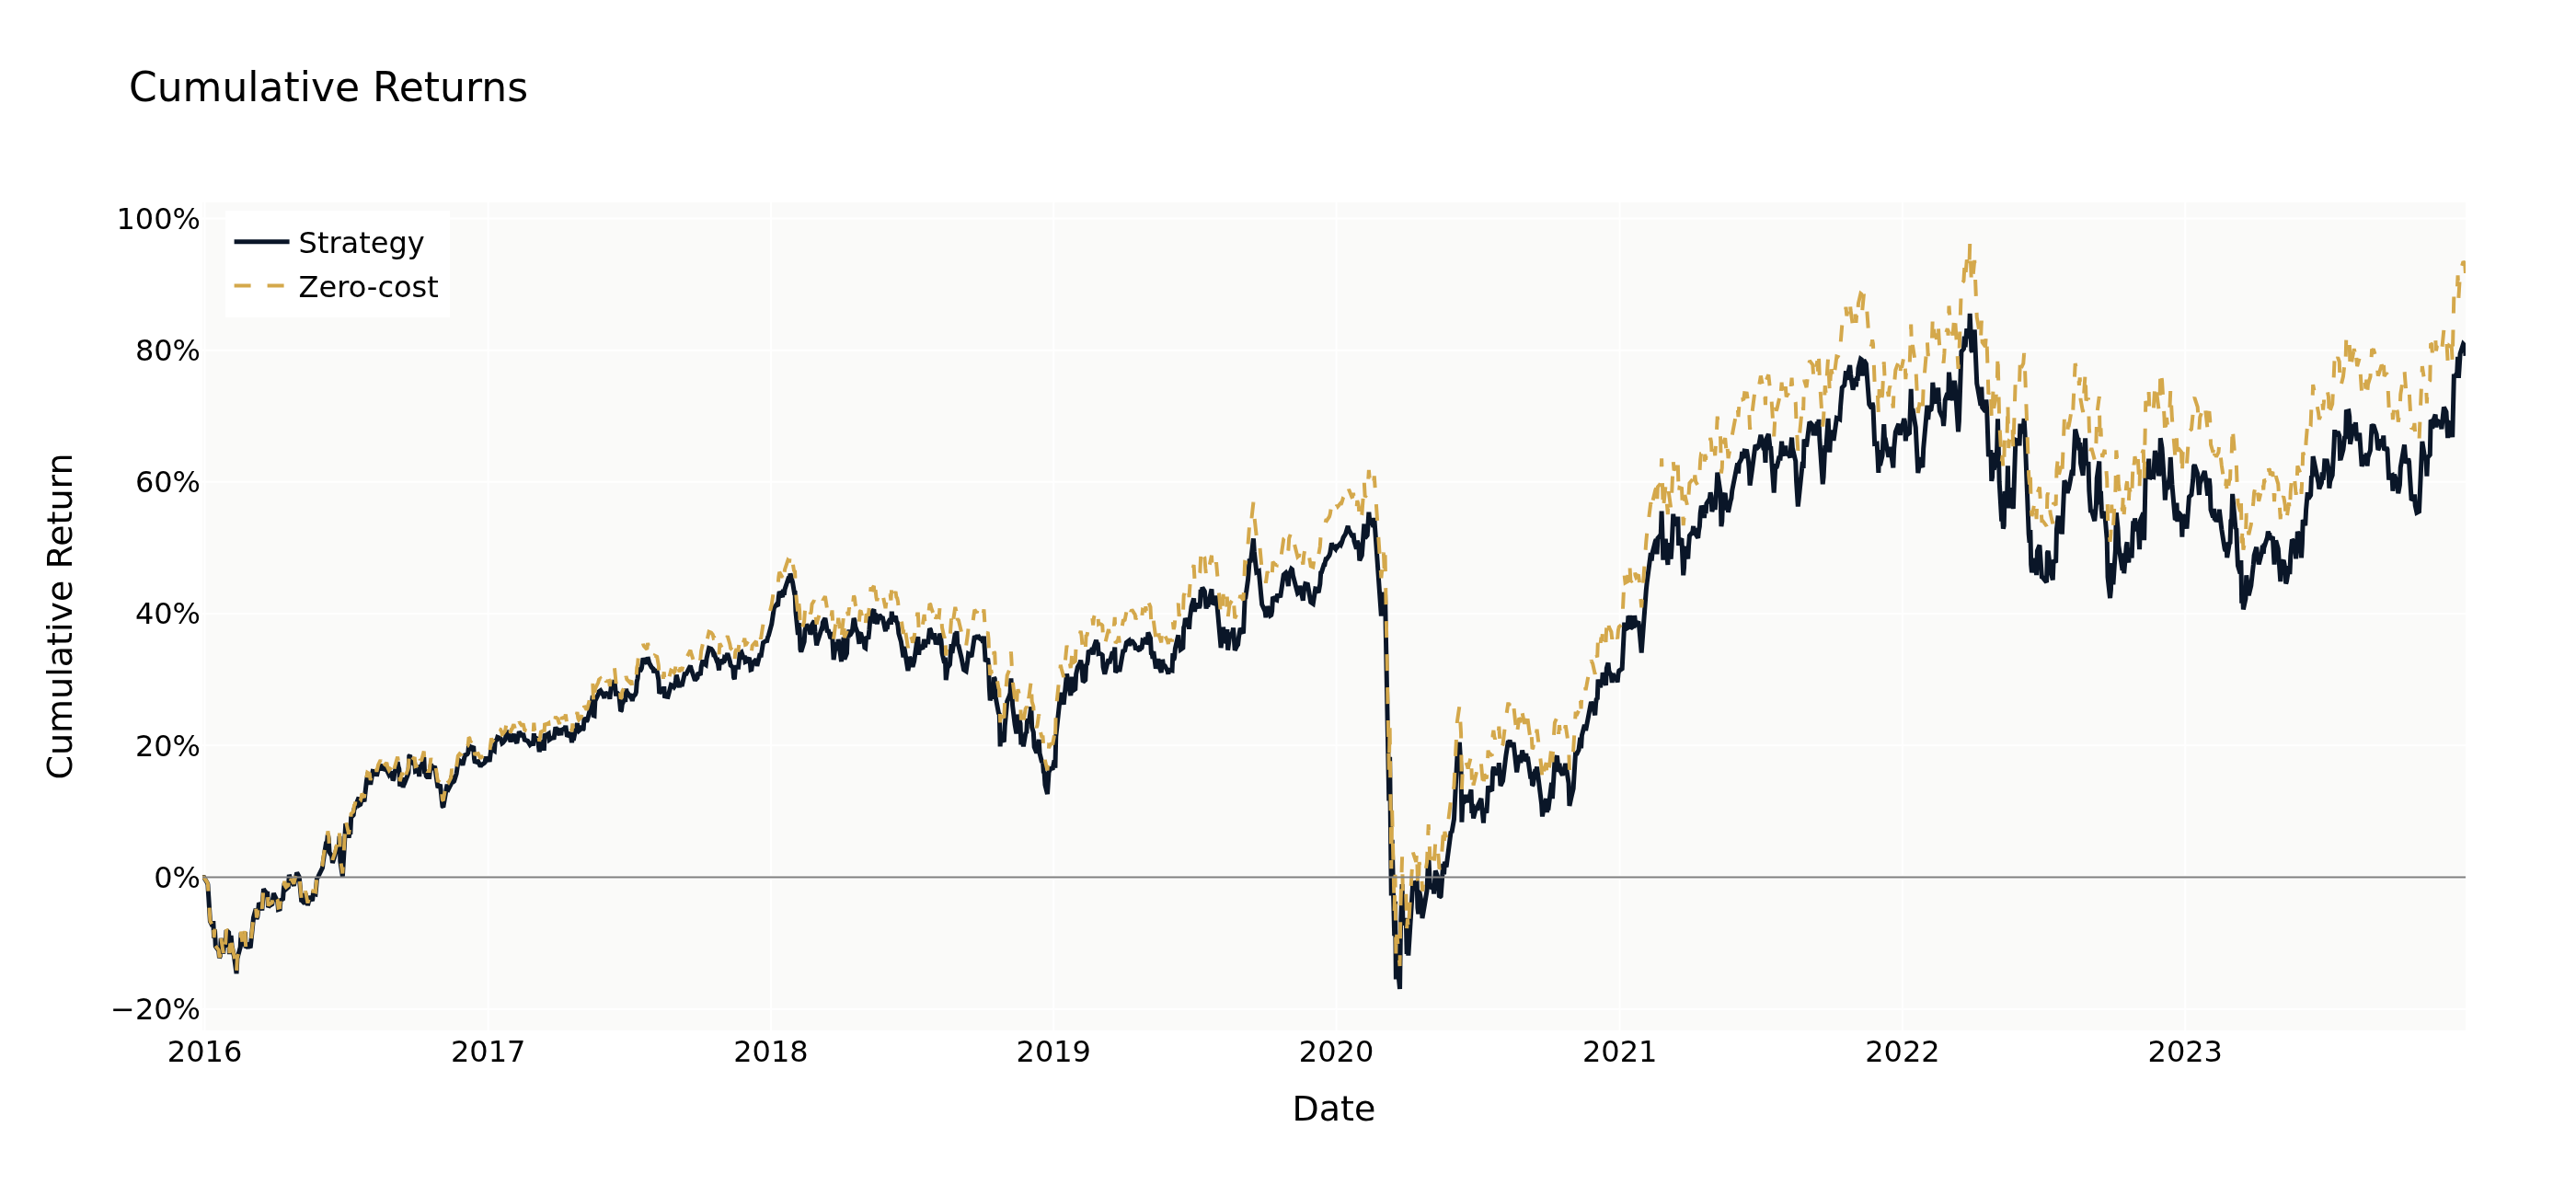

In [7]:
from pathlib import Path

from IPython.display import Image
from ml4t.diagnostic.evaluation.portfolio_analysis import PortfolioAnalysis
from ml4t.diagnostic.visualization.portfolio.drawdown_plots import plot_drawdown_underwater
from ml4t.diagnostic.visualization.portfolio.returns_plots import plot_cumulative_returns

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

# "presentation" is ml4t-diagnostic's high-contrast theme. The "print" theme is grayscale,
# which turns a two-line chart into two lines nobody can tell apart on a projector.
THEME = "presentation"


def show(fig, filename, width=1400, height=650):
    """Write a Plotly figure to figures/ and display it as a static image.

    Plotly returns a JSON mime bundle that only draws where a live Plotly frontend is
    loaded, so a saved notebook shows blank cells on GitHub and offline. Displaying the
    exported PNG keeps every chart visible in the committed notebook and in a live run.
    """
    path = FIGURE_DIR / filename
    fig.write_image(path, width=width, height=height, scale=2)
    return Image(filename=str(path), width=width)


def equity_returns(result):
    equity = pd.DataFrame(result.equity_curve, columns=["timestamp", "value"])
    equity["timestamp"] = pd.to_datetime(equity["timestamp"])
    return equity.set_index("timestamp")["value"].pct_change().dropna()


zero_cost_returns = equity_returns(result_zero_cost)
with_costs_returns = equity_returns(result_with_costs)
common_dates = zero_cost_returns.index.intersection(with_costs_returns.index)

analysis = PortfolioAnalysis(
    returns=with_costs_returns.loc[common_dates],
    benchmark=zero_cost_returns.loc[common_dates],
    dates=common_dates,
)

returns_fig = plot_cumulative_returns(analysis, benchmark_label="Zero-cost", theme=THEME)
returns_fig.update_layout(margin=dict(l=110, r=60, t=110, b=90))
show(returns_fig, "backtest-cost-gap.png")

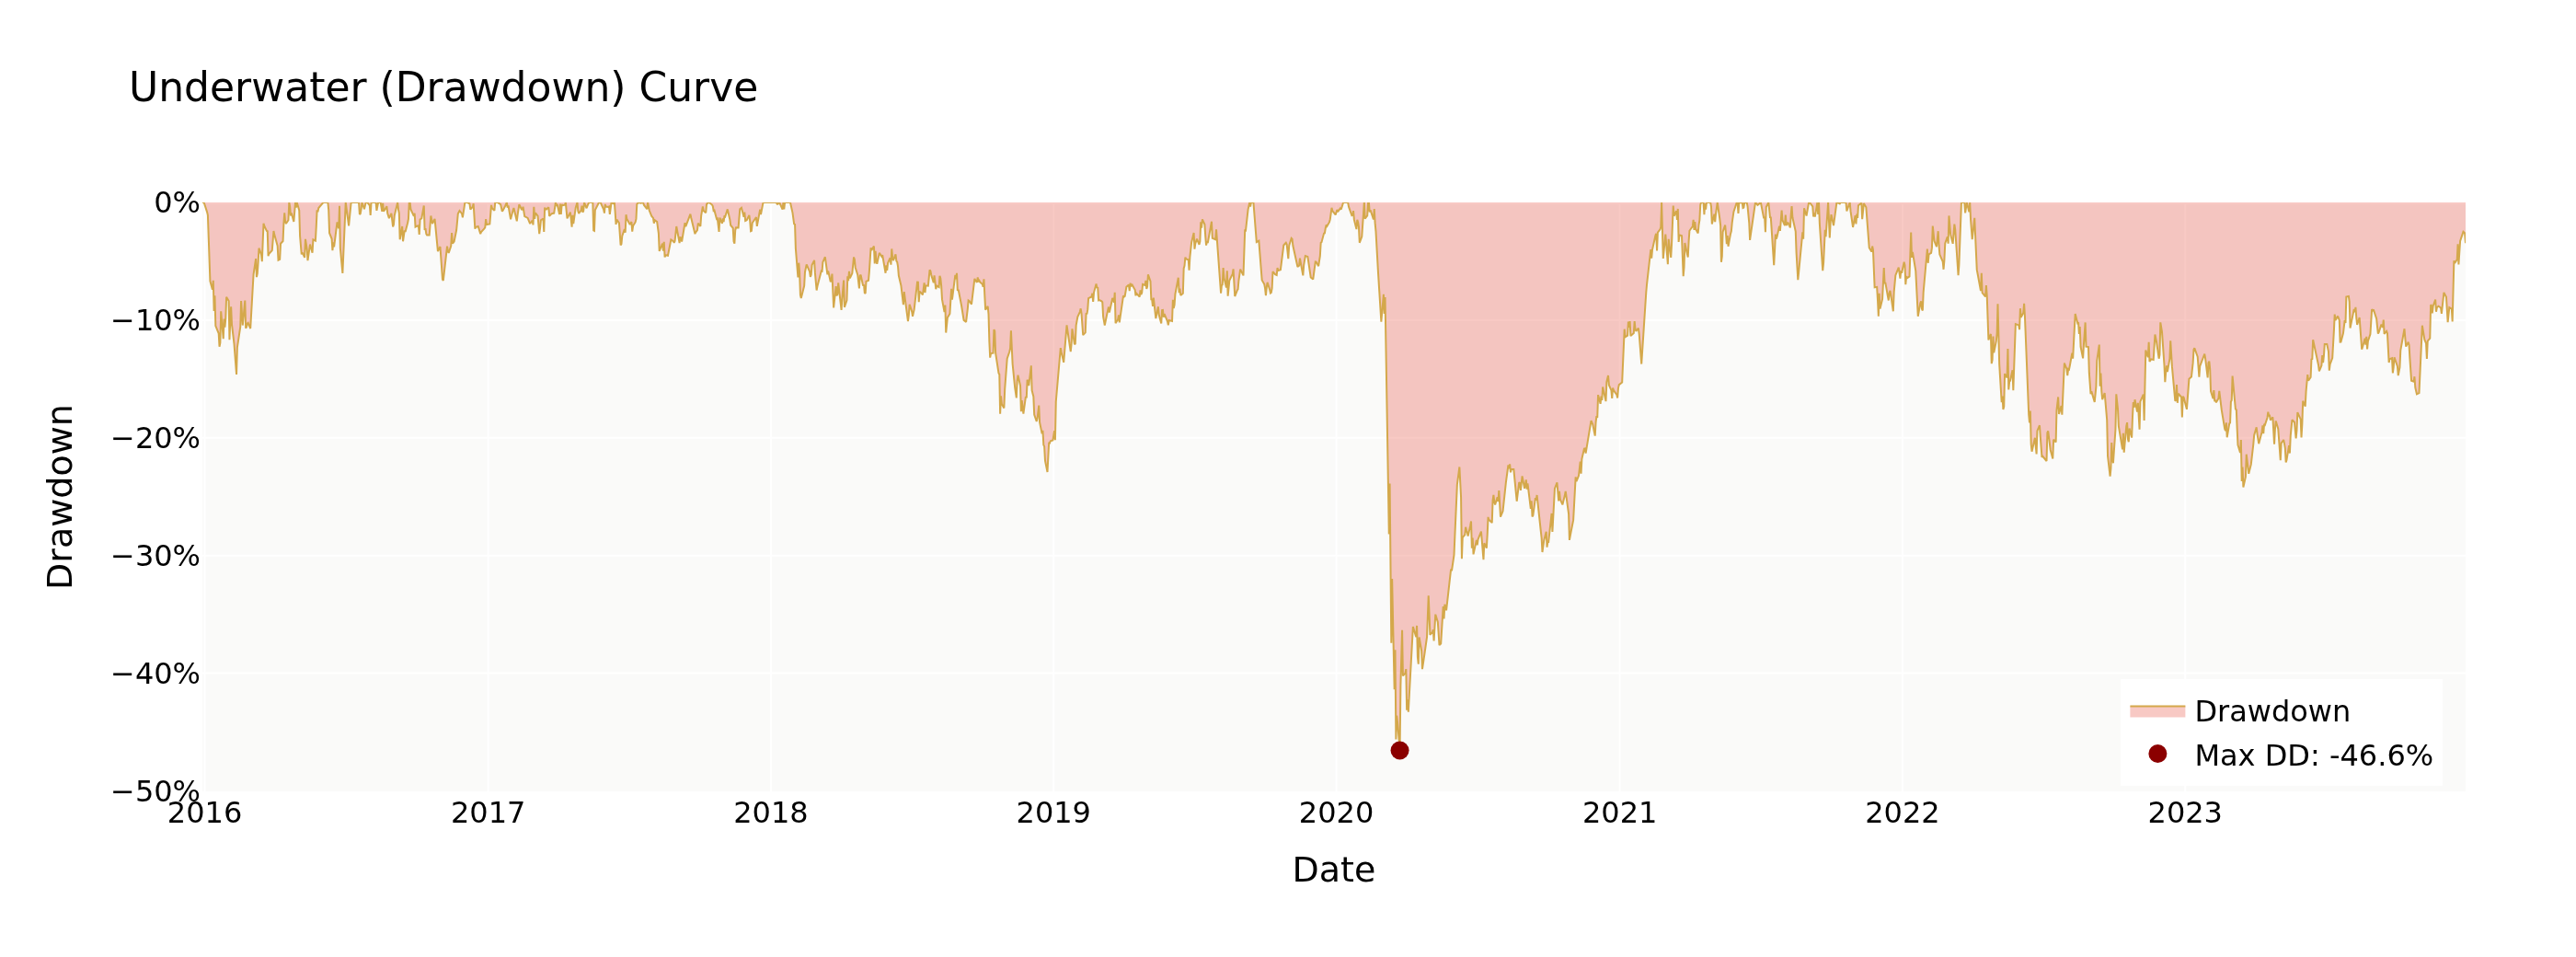

In [8]:
drawdown_fig = plot_drawdown_underwater(analysis, theme=THEME, height=460)
drawdown_fig.update_layout(margin=dict(l=110, r=60, t=110, b=90))
show(drawdown_fig, "backtest-drawdown.png", height=520)

## One backtest, read from several angles

A single Sharpe ratio is one summary of one path. `ml4t-diagnostic` computes the rest of
the standard views from the same return series, and they disagree with each other in
useful ways: the annual bars show which years carried the result, the rolling Sharpe shows
whether the edge was ever stable, and the monthly heatmap shows how much of it arrived in
a handful of months.

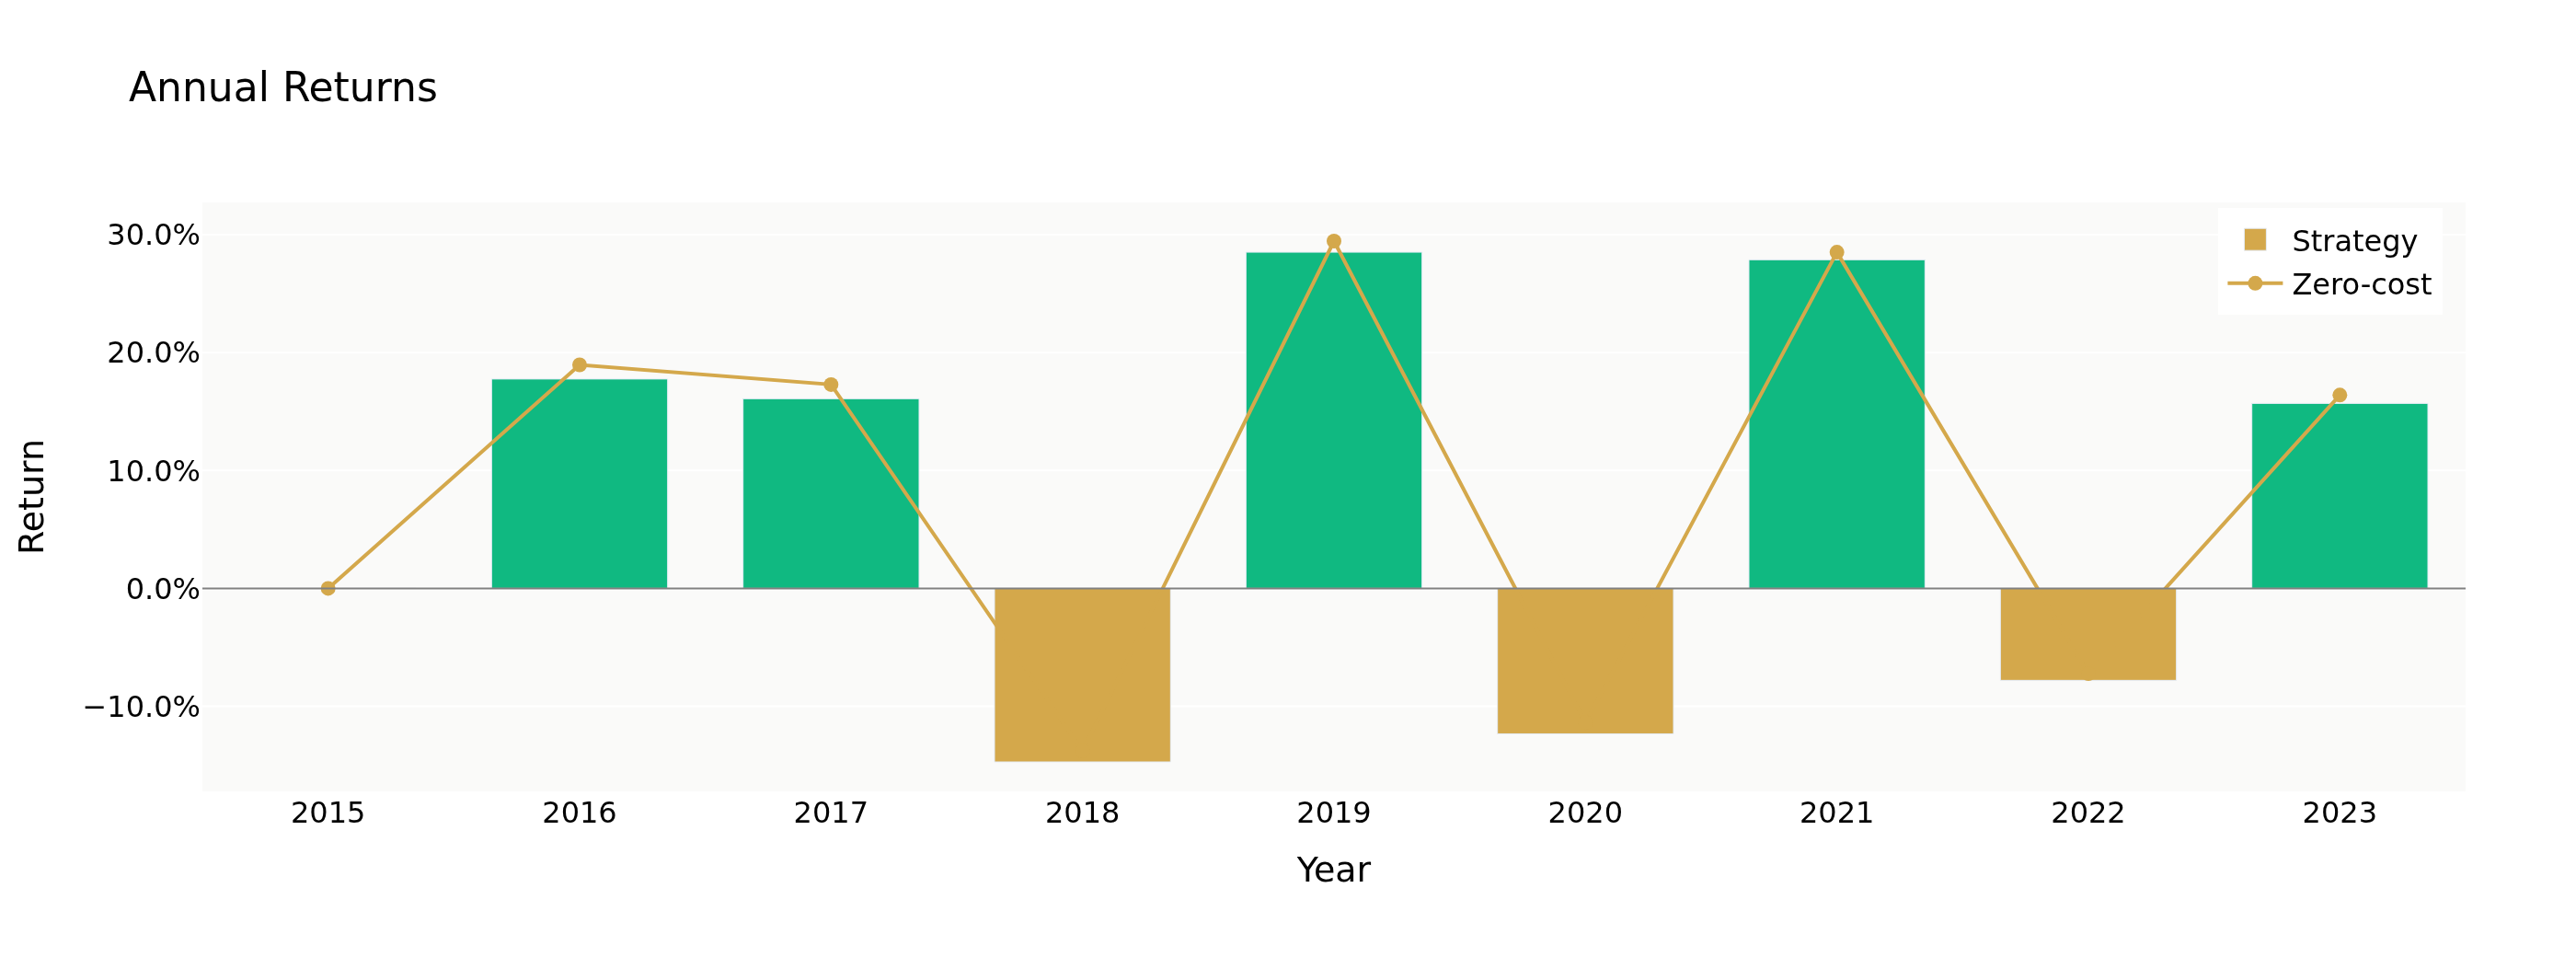

In [9]:
from ml4t.diagnostic.visualization.portfolio.returns_plots import plot_annual_returns_bar
from ml4t.diagnostic.visualization.portfolio.risk_plots import plot_rolling_sharpe

annual_fig = plot_annual_returns_bar(analysis, benchmark_label="Zero-cost", theme=THEME)
annual_fig.update_layout(margin=dict(l=110, r=60, t=110, b=90))
show(annual_fig, "backtest-annual-returns.png", height=520)

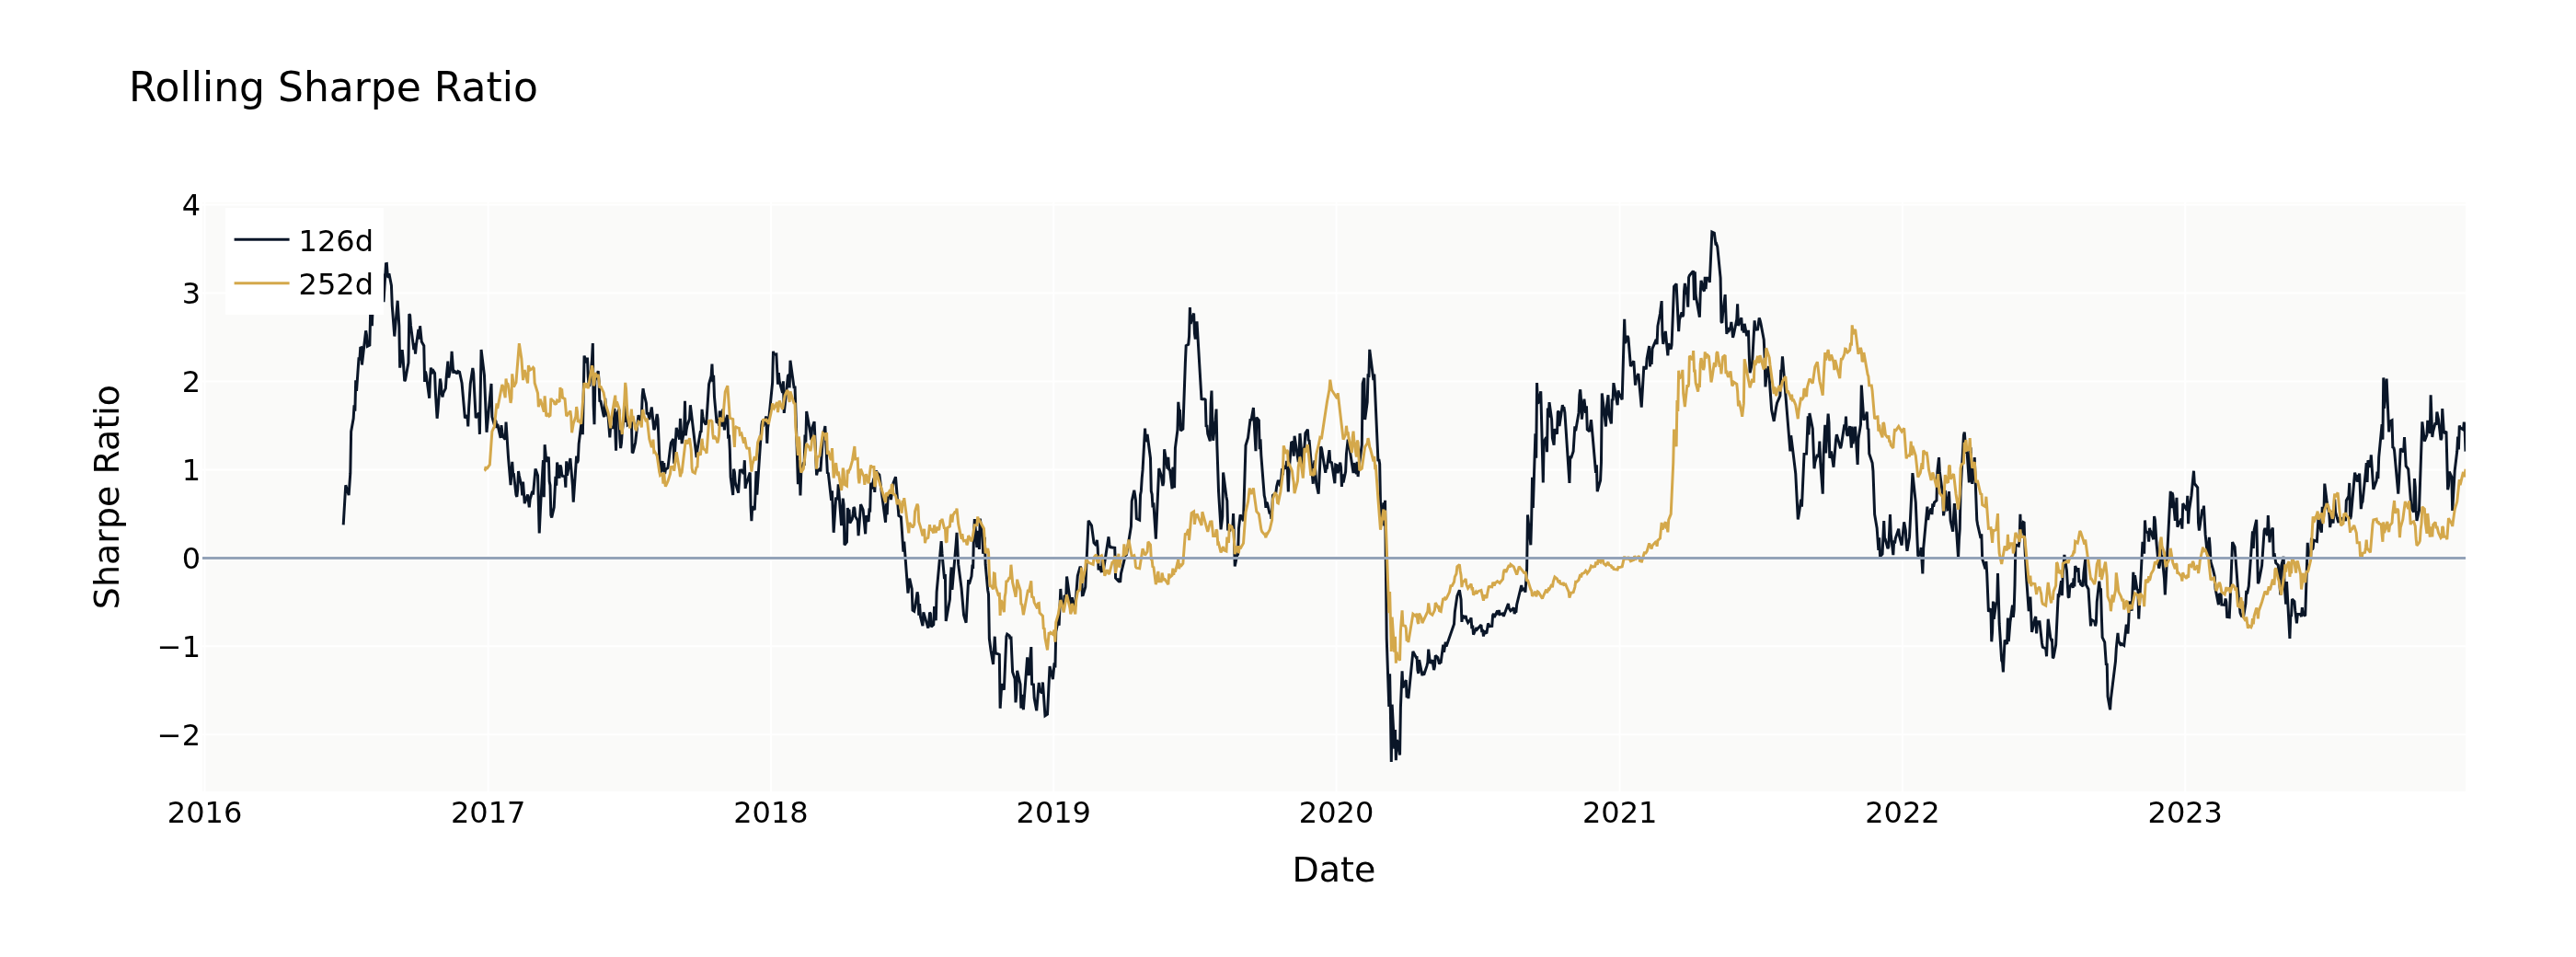

In [10]:
rolling_sharpe_fig = plot_rolling_sharpe(analysis, windows=[126, 252], theme=THEME, height=460)
# The library draws "Good (1.0)" and "Excellent (2.0)" guide lines whose labels sit on top
# of the series at the right edge. The labels are also a verdict this deck does not want to
# hand out - the point of the chart is the swing, not a grade.
rolling_sharpe_fig.layout.shapes = ()
rolling_sharpe_fig.layout.annotations = ()
rolling_sharpe_fig.add_hline(y=0, line=dict(color="#94a3b8", width=1.5))
rolling_sharpe_fig.update_layout(margin=dict(l=110, r=60, t=110, b=90))
show(rolling_sharpe_fig, "backtest-rolling-sharpe.png", height=520)

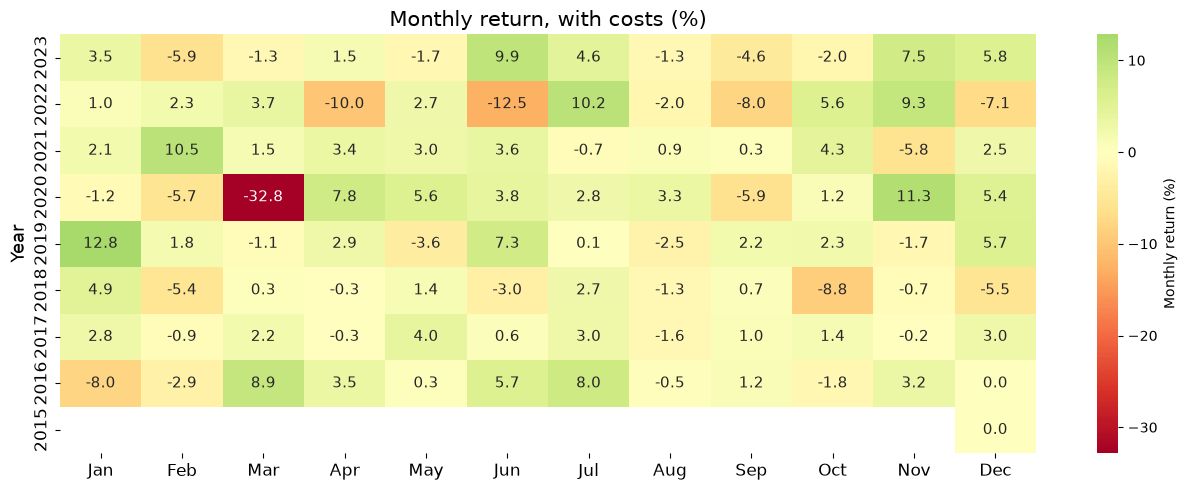

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ml4t-diagnostic<=0.1.0b25's plot_monthly_returns_heatmap lays its cells out by position
# rather than by month number, so a return series that does not begin in January shifts
# every cell one column per missing month. This backtest starts 2015-12-29, which pushed
# the -32.8% COVID month into April. Reproduced with synthetic data: a series starting in
# December renders a March loss under "Apr"; the same series starting in January is correct.
# `get_monthly_returns_matrix()` itself is right - only the plot misaligns - so this builds
# the view directly. Drop once the pin moves past b25.
monthly = ((1 + with_costs_returns.loc[common_dates]).resample("ME").prod() - 1).to_frame("ret")
monthly["year"] = monthly.index.year
monthly["month"] = monthly.index.month
monthly_matrix = monthly.pivot(index="year", columns="month", values="ret").sort_index(
    ascending=False
)
monthly_matrix.columns = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
][: monthly_matrix.shape[1]]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    monthly_matrix * 100,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 11},
    ax=ax,
    cbar_kws={"label": "Monthly return (%)"},
)
ax.set_xlabel("")
ax.set_ylabel("Year", fontsize=13)
ax.set_title("Monthly return, with costs (%)", fontsize=15)
ax.tick_params(labelsize=12)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "backtest-monthly-returns.png", dpi=150)
plt.show()

assert abs(monthly_matrix.loc[2020, "Mar"] + 0.3284) < 1e-3, "COVID month moved"

The summary statistics restate the same eight years in the conventional vocabulary. Read
them next to the rolling chart above rather than on their own: every one of these is a
full-sample average over a period the rolling view has already shown to be uneven.

In [12]:
metrics = analysis.compute_summary_stats()

# compute_summary_stats returns a PortfolioMetrics dataclass; printing it raw is one
# unreadable line, so pull out the views that answer different questions about the same path.
rows = [
    ("Total return", metrics.total_return, "{:.1%}"),
    ("Annualized return", metrics.annual_return, "{:.1%}"),
    ("Annualized volatility", metrics.annual_volatility, "{:.1%}"),
    ("Sharpe ratio", metrics.sharpe_ratio, "{:.2f}"),
    ("Sortino ratio", metrics.sortino_ratio, "{:.2f}"),
    ("Calmar ratio", metrics.calmar_ratio, "{:.2f}"),
    ("Maximum drawdown", metrics.max_drawdown, "{:.1%}"),
    ("Return skewness", metrics.skewness, "{:.2f}"),
    ("Return kurtosis", metrics.kurtosis, "{:.1f}"),
    ("Daily VaR (95%)", metrics.var_95, "{:.2%}"),
    ("Daily CVaR (95%)", metrics.cvar_95, "{:.2%}"),
    ("Share of winning days", metrics.win_rate, "{:.1%}"),
]
print(f"{'Metric':<26}{'With costs':>12}")
for label, value, fmt in rows:
    print(f"{label:<26}{fmt.format(value):>12}")

Metric                      With costs
Total return                     79.1%
Annualized return                 7.6%
Annualized volatility            22.3%
Sharpe ratio                      0.44
Sortino ratio                     0.40
Calmar ratio                      0.16
Maximum drawdown                -46.6%
Return skewness                  -1.56
Return kurtosis                   20.4
Daily VaR (95%)                 -1.93%
Daily CVaR (95%)                -3.24%
Share of winning days            53.2%


## Read this like a practitioner, not a scoreboard

`03_model_training` already showed a HAC-corrected IC that isn't
distinguishable from noise (t ≈ 0.94). Whatever this backtest reports
is the honest downstream consequence of that - not a separate, better
story. Two things worth checking regardless of the top-line number:

- **The cost gap.** `with_costs` vs `zero_cost` on the *same* signal,
  same rebalance dates, same ranking - the only thing that changed is
  whether commissions and spread are switched on. That gap is what
  "cost-aware" means in practice, not a modifier applied after the fact.
- **Turnover.** A monthly top-10-of-100 rebalance can still churn
  heavily if the ranking is unstable month to month; check
  `result_with_costs.trades` before trusting any Sharpe number here.

Across the eight validation folds from late 2015 through 2023, this
strategy's Sharpe drops from 0.48 (zero cost) to 0.44 (with costs) - a
real but modest reduction because monthly rebalancing keeps turnover near
6.0% per rebalance. Commissions and spread total **$8,597 on a $100,000
starting account**. The 2024-2025 holdout remains sealed; this result is
validation evidence, not a final test result.

In [13]:
trades = pd.DataFrame([asdict(t) for t in result_with_costs.trades])
print(f"trades (with costs): {len(trades)}")
assert len(trades) == 597
trades.head()

trades (with costs): 597


,symbol,entry_time,exit_time,entry_price,exit_price,quantity,pnl,pnl_percent,bars_held,fees,...,entry_bid_price,entry_ask_price,entry_spread,entry_available_size,exit_quote_mid_price,exit_bid_price,exit_ask_price,exit_spread,exit_available_size,metadata
0,USO,2016-01-04,2016-02-01,90.100002,74.780003,114.0,-1747.277861,-0.170033,19,0.798,...,None,None,None,4529588.0,None,None,None,None,6111225.0,None
1,ITB,2016-01-04,2016-02-01,24.917991,22.560167,395.0,-934.105327,-0.094623,19,2.765,...,None,None,None,5917100.0,None,None,None,None,3974800.0,None
2,EWQ,2016-01-04,2016-02-01,18.164260,17.665485,540.0,-273.118435,-0.027459,19,3.780,...,None,None,None,1311800.0,None,None,None,None,1073800.0,None
3,XLY,2016-01-04,2016-02-01,34.413639,33.004591,286.0,-404.989496,-0.040944,19,2.002,...,None,None,None,26800800.0,None,None,None,None,16598800.0,None
4,IVW,2016-01-04,2016-02-01,25.661245,24.609125,383.0,-405.642876,-0.041000,19,2.681,...,None,None,None,10287200.0,None,None,None,None,3823200.0,None


**Next:** `05_research_agent_trace.ipynb` - agenda block 9's research-agent
segment, walked through as one real, already-run pipeline trace rather
than a live LLM call. Block 10 ("where to go next") is slides only - see
the closing slides for what comes after "the backtest looks weak, now
what."